<a href="https://colab.research.google.com/github/GScaramussa/Redes/blob/main/redesCSMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Simulação do protocolo CSMA não persistente não segmentado (unslotted)

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import time

def simular_csma_npersistente(
    tempo=0.01,
    n_est=10,
    taxa_bits=1e5,
    tam_quadro=100,
    espera_max_factor=10,
    rodadas=3,
    a=0.05,
    pontos=15,
    seed=42
):
    rng = np.random.default_rng(seed)

    # Parâmetros derivados
    t_quadro = tam_quadro / taxa_bits
    dt_sim = t_quadro / tam_quadro
    t_sim = int(np.ceil(tempo / dt_sim))
    duracao_tx = int(np.ceil(tam_quadro / taxa_bits / dt_sim))

    taxa_max_quadro = int(np.ceil(taxa_bits / tam_quadro / n_est))
    taxas_quadro = taxa_max_quadro * np.arange(1 / pontos, 1 + 1 / pontos, 1 / pontos)

    # Resultados
    quadros_entregues = np.zeros(pontos)
    quadros_colididos = np.zeros(pontos)
    quadros_bloqueados = np.zeros(pontos)

    for idx, taxa_quadro in enumerate(taxas_quadro):
        tm_q = taxa_quadro * dt_sim
        espera_max = int(np.ceil(espera_max_factor * duracao_tx))
        atraso = int(np.ceil(a * tam_quadro))

        for _ in range(rodadas):
            tx_ativo = np.zeros(n_est, dtype=int)
            tx_fila = np.zeros(n_est, dtype=int)
            tx_cnt = np.zeros(n_est, dtype=int)
            colin = np.zeros(n_est, dtype=int)
            tx_espera = np.zeros(n_est, dtype=int)
            transmis = np.zeros((n_est, t_sim), dtype=int)

            colisoes = 0
            entregues = 0
            bloqueios = 0

            for k in range(t_sim):
                if k > atraso:
                    tx_ativo_atr = transmis[:, k - atraso]
                else:
                    tx_ativo_atr = np.zeros(n_est, dtype=int)

                for j in range(n_est):
                    # Se está transmitindo, registra no meio
                    if tx_ativo[j] == 1:
                        transmis[j, k] = 1

                    # Se já iniciou transmissão, avança contador
                    if tx_cnt[j] > 0:
                        tx_cnt[j] -= 1

                        if tx_cnt[j] == 0:
                            tx_ativo[j] = 0

                            if colin[j] == 1:
                                tx_espera[j] = int(np.ceil(espera_max * rng.random()))
                                tx_fila[j] += 1
                                colin[j] = 0
                                colisoes += 1
                            else:
                                entregues += 1

                    else:
                        # Se há quadro na fila, tentar transmitir
                        if tx_fila[j] > 0:
                            if (tx_espera[j] == 0) and (np.count_nonzero(tx_ativo_atr) == 0):
                                tx_ativo[j] = 1
                                tx_cnt[j] = duracao_tx
                                tx_fila[j] -= 1

                            elif tx_espera[j] > 0:
                                tx_espera[j] -= 1

                            elif np.count_nonzero(tx_ativo_atr) > 0:
                                tx_espera[j] = int(np.ceil(espera_max * rng.random()))
                                bloqueios += 1

                    # Geração de novo quadro
                    if rng.random() < tm_q:
                        if (tx_ativo[j] == 0) and (tx_espera[j] == 0) and (np.count_nonzero(tx_ativo_atr) == 0):
                            tx_ativo[j] = 1
                            tx_cnt[j] = duracao_tx
                        else:
                            tx_fila[j] += 1

                            if (tx_espera[j] == 0) and (np.count_nonzero(tx_ativo_atr) > 0):
                                tx_espera[j] = int(np.ceil(espera_max * rng.random()))
                                bloqueios += 1

                # Verifica colisão no instante
                if np.count_nonzero(tx_ativo) > 1:
                    colin = np.logical_or(colin, tx_ativo).astype(int)

            quadros_entregues[idx] += entregues / rodadas
            quadros_colididos[idx] += colisoes / rodadas
            quadros_bloqueados[idx] += bloqueios / rodadas

    # Curva teórica
    G = np.arange(0, 1.51, 0.01)
    S = (G * np.exp(-a * G)) / (G * (1 + 2 * a) + np.exp(-a * G))

    # Curva simulada
    x_sim = (quadros_colididos + quadros_entregues + quadros_bloqueados) * tam_quadro / tempo
    y_sim = quadros_entregues * tam_quadro / tempo

    # Curva teórica em bps
    x_teo = G * taxa_bits
    y_teo = S * taxa_bits

    return {
        "x_sim": x_sim,
        "y_sim": y_sim,
        "x_teo": x_teo,
        "y_teo": y_teo
    }


def plot_variacao_relatorio(parametro, valores, base_params, titulo, legenda_fmt,
                            arquivo_saida, teoria_modo="unica"):
    plt.figure(figsize=(9, 6))
    teoria_plotada = False

    for i, valor in enumerate(valores):
        params = base_params.copy()
        params[parametro] = valor
        params["seed"] = base_params.get("seed", 42) + i

        r = simular_csma_npersistente(**params)

        linha, = plt.plot(
            r["x_sim"], r["y_sim"], "o-",
            linewidth=1.6, markersize=4,
            label=f"Simulação — {legenda_fmt(valor)}"
        )

        if teoria_modo == "por_curva":
            plt.plot(
                r["x_teo"], r["y_teo"], "--",
                linewidth=1.5,
                color=linha.get_color(),
                label=f"Teoria — {legenda_fmt(valor)}"
            )
        elif not teoria_plotada:
            plt.plot(
                r["x_teo"], r["y_teo"], "k--",
                linewidth=2,
                label="Teoria"
            )
            teoria_plotada = True

    plt.grid(True)
    plt.xlabel("Taxa de geração / carga oferecida (bps)")
    plt.ylabel("Taxa de entrega / capacidade (bps)")
    plt.title(titulo)
    plt.legend()
    plt.tight_layout()
    plt.savefig(arquivo_saida, dpi=300, bbox_inches="tight")
    plt.show()


# Parâmetros-base
base = {
    "tempo": 0.01,
    "n_est": 10,
    "taxa_bits": 1e5,
    "tam_quadro": 100,
    "espera_max_factor": 10,
    "rodadas": 3,
    "a": 0.05,
    "pontos": 15,
    "seed": 42
}

Tempo de execução para a = 0.03: 0.6094 s


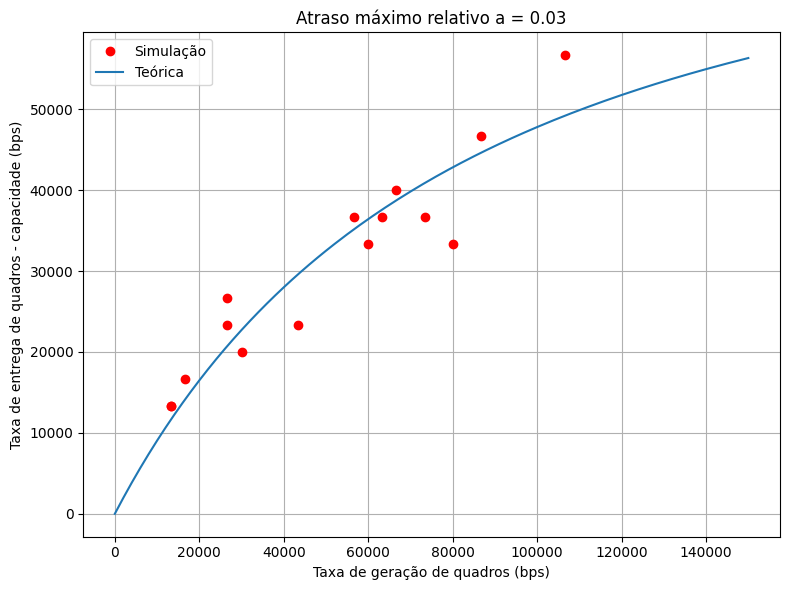

Tempo de execução para a = 0.05: 1.1153 s


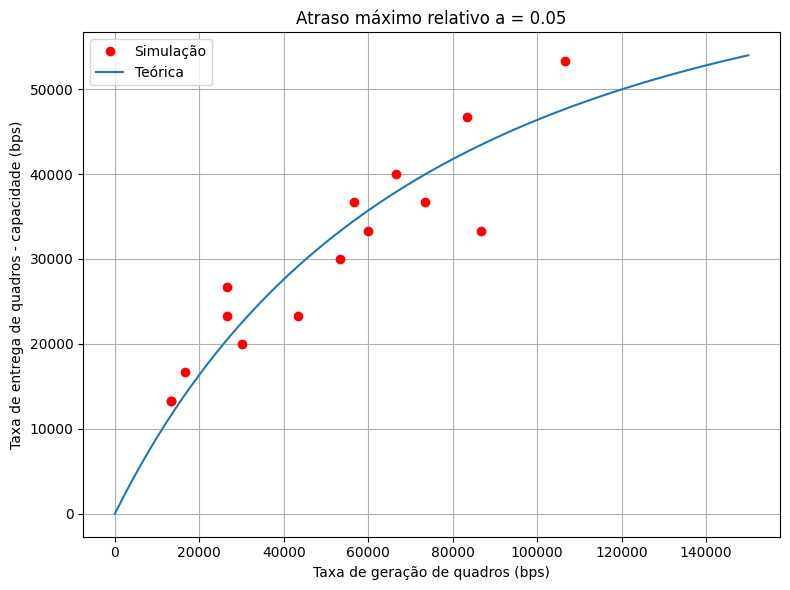

Tempo de execução para a = 0.1: 0.6135 s


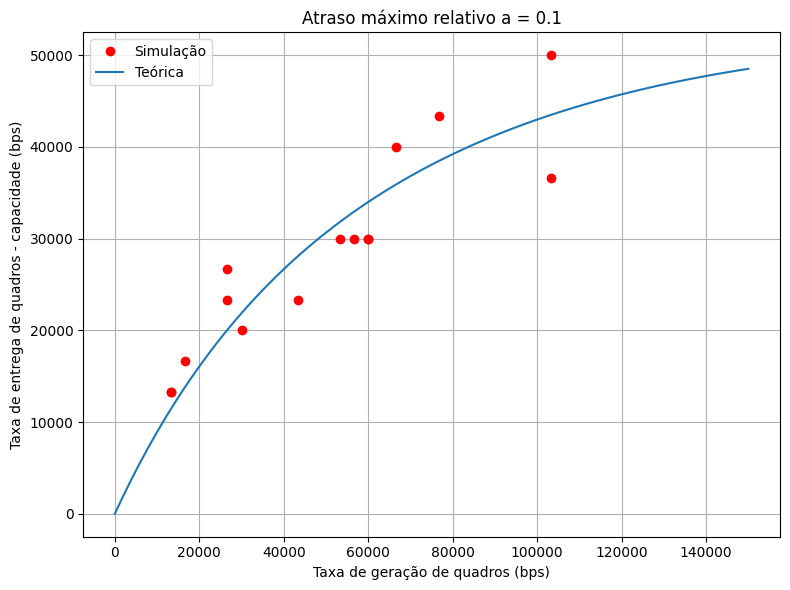

In [16]:
valores_a_iniciais = [0.03, 0.05, 0.1]

for a_val in valores_a_iniciais:
    params = base.copy()
    params["a"] = a_val

    inicio = time.time()
    r = simular_csma_npersistente(**params)
    fim = time.time()

    print(f"Tempo de execução para a = {a_val}: {fim - inicio:.4f} s")

    plt.figure(figsize=(8, 6))
    plt.plot(r["x_sim"], r["y_sim"], "ro", label="Simulação")
    plt.plot(r["x_teo"], r["y_teo"], "-", label="Teórica")
    plt.grid(True)
    plt.title(f"Atraso máximo relativo a = {a_val}")
    plt.xlabel("Taxa de geração de quadros (bps)")
    plt.ylabel("Taxa de entrega de quadros - capacidade (bps)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"grafico_inicial_a_{str(a_val).replace('.', '_')}.png", dpi=300, bbox_inches="tight")
    plt.show()

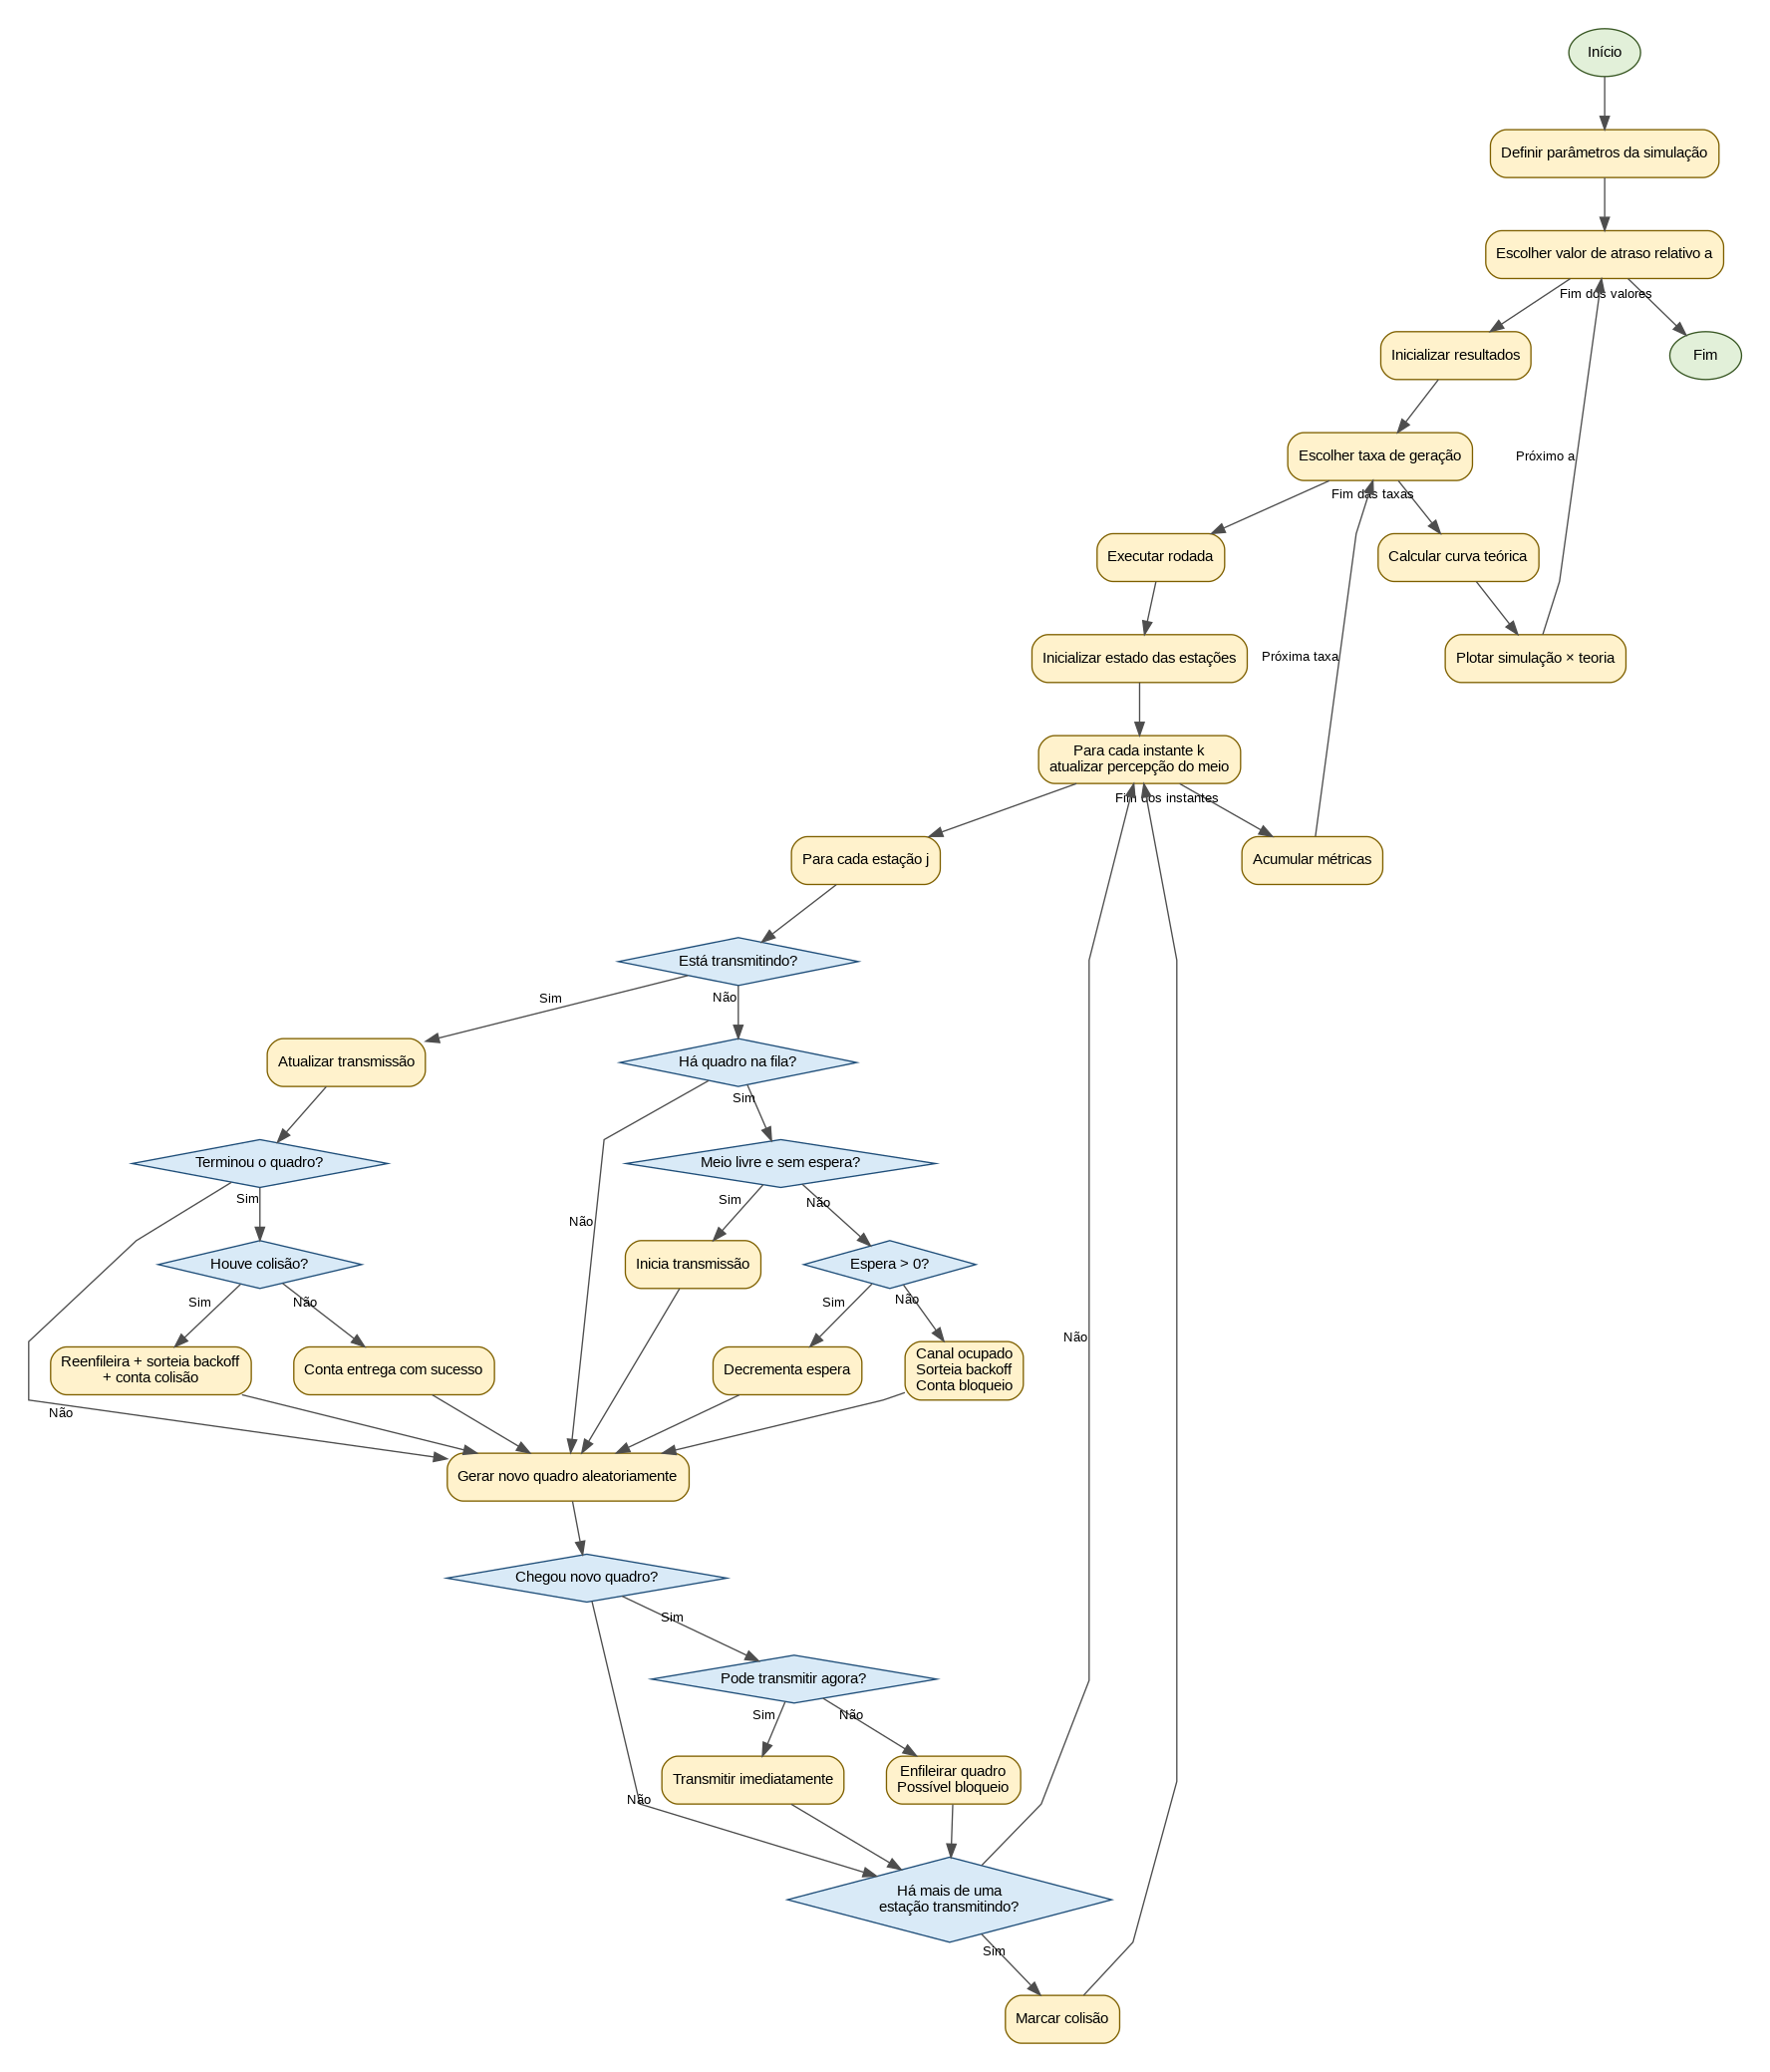

In [17]:
!apt-get -qq install graphviz
!pip -q install graphviz

from graphviz import Digraph
from IPython.display import Image, display

dot = Digraph('CSMA_Fluxograma')
dot.attr(rankdir='TB', splines='polyline', pad='0.3', nodesep='0.45', ranksep='0.55')
dot.attr('edge', fontname='Arial', fontsize='10', color='gray30')

def proc(id_, txt):
    dot.node(id_, txt, shape='rectangle', style='rounded,filled',
             fillcolor='#FFF2CC', color='#7F6000', fontname='Arial', fontsize='11')

def decis(id_, txt):
    dot.node(id_, txt, shape='diamond', style='filled',
             fillcolor='#D9EAF7', color='#1F4E79', fontname='Arial', fontsize='11')

def term(id_, txt):
    dot.node(id_, txt, shape='oval', style='filled',
             fillcolor='#E2F0D9', color='#385723', fontname='Arial', fontsize='11')

term('A', 'Início')
proc('B', 'Definir parâmetros da simulação')
proc('C', 'Escolher valor de atraso relativo a')
proc('D', 'Inicializar resultados')
proc('E', 'Escolher taxa de geração')
proc('F', 'Executar rodada')
proc('G', 'Inicializar estado das estações')
proc('H', 'Para cada instante k\natualizar percepção do meio')
proc('I', 'Para cada estação j')
decis('J', 'Está transmitindo?')
proc('K', 'Atualizar transmissão')
decis('L', 'Terminou o quadro?')
decis('M', 'Houve colisão?')
proc('N', 'Reenfileira + sorteia backoff\n+ conta colisão')
proc('O', 'Conta entrega com sucesso')
decis('P', 'Há quadro na fila?')
decis('Q', 'Meio livre e sem espera?')
proc('R', 'Inicia transmissão')
decis('S', 'Espera > 0?')
proc('T', 'Decrementa espera')
proc('U', 'Canal ocupado\nSorteia backoff\nConta bloqueio')
proc('V', 'Gerar novo quadro aleatoriamente')
decis('W', 'Chegou novo quadro?')
decis('X', 'Pode transmitir agora?')
proc('Y', 'Transmitir imediatamente')
proc('Z', 'Enfileirar quadro\nPossível bloqueio')
decis('AA', 'Há mais de uma\nestação transmitindo?')
proc('AB', 'Marcar colisão')
proc('AC', 'Acumular métricas')
proc('AD', 'Calcular curva teórica')
proc('AE', 'Plotar simulação × teoria')
term('AF', 'Fim')

arestas = [
    ('A','B',''), ('B','C',''), ('C','D',''), ('D','E',''), ('E','F',''),
    ('F','G',''), ('G','H',''), ('H','I',''), ('I','J',''),
    ('J','K','Sim'), ('J','P','Não'),
    ('K','L',''), ('L','M','Sim'), ('L','V','Não'),
    ('M','N','Sim'), ('M','O','Não'),
    ('N','V',''), ('O','V',''),
    ('P','Q','Sim'), ('P','V','Não'),
    ('Q','R','Sim'), ('Q','S','Não'),
    ('S','T','Sim'), ('S','U','Não'),
    ('R','V',''), ('T','V',''), ('U','V',''),
    ('V','W',''),
    ('W','X','Sim'), ('W','AA','Não'),
    ('X','Y','Sim'), ('X','Z','Não'),
    ('Y','AA',''), ('Z','AA',''),
    ('AA','AB','Sim'), ('AA','H','Não'),
    ('AB','H',''),
    ('H','AC','Fim dos instantes'),
    ('AC','E','Próxima taxa'),
    ('E','AD','Fim das taxas'),
    ('AD','AE',''),
    ('AE','C','Próximo a'),
    ('C','AF','Fim dos valores')
]

for u, v, lbl in arestas:
    if lbl:
        dot.edge(u, v, xlabel=lbl)   # usar xlabel em vez de label
    else:
        dot.edge(u, v)

arquivo = dot.render(filename='fluxograma_csma', format='png', cleanup=True)
display(Image(filename=arquivo))

## Fluxograma
A simulação modela um sistema com várias estações compartilhando um meio comum de transmissão, sob a lógica do protocolo CSMA não-persistente. Inicialmente, são definidos os parâmetros do sistema, como número de estações, taxa de transmissão, tamanho do quadro, duração da simulação e atraso de propagação relativo. Em seguida, para cada valor de atraso e para cada taxa de geração de quadros, o programa executa várias rodadas de simulação. Em cada rodada, cada estação pode gerar quadros aleatoriamente ao longo do tempo. Quando uma estação possui quadro para transmitir, ela verifica o estado do meio; se o canal estiver livre, inicia a transmissão, e se estiver ocupado, espera um intervalo aleatório antes de tentar novamente, conforme a lógica não-persistente. O estado percebido do meio considera um atraso de propagação, o que permite que duas ou mais estações interpretem simultaneamente que o canal está livre e iniciem transmissão ao mesmo tempo, produzindo colisões. Quando há colisão, o quadro não é considerado entregue, retorna à fila da estação e aguarda nova tentativa após um tempo de espera aleatório. Ao final de cada experimento, o programa contabiliza quadros gerados, entregues, colididos e bloqueados, e compara o resultado médio obtido com a expressão teórica do CSMA não-persistente.

## Diferenças entre simulação e situação real
Na simulação, o funcionamento da rede é representado de forma simplificada para permitir a análise do protocolo CSMA não-persistente, mas esse modelo não reproduz integralmente todas as condições de uma situação real. Em primeiro lugar, o tempo é tratado de forma discretizada, isto é, dividido em pequenos intervalos fixos, enquanto em uma rede real os eventos ocorrem de maneira contínua. Além disso, a geração de quadros é feita por meio de um processo aleatório simples, com probabilidade constante a cada instante, o que facilita os cálculos, mas não representa perfeitamente o tráfego real, que costuma variar ao longo do tempo e pode ocorrer em rajadas. Outro ponto é que todas as estações são consideradas iguais no modelo, com o mesmo comportamento, a mesma taxa de transmissão e as mesmas regras de espera, ao passo que, na prática, diferentes dispositivos podem apresentar capacidades, cargas e tempos de resposta distintos.

Também há simplificações em relação ao meio de transmissão. Na simulação, o canal é modelado basicamente a partir do atraso de propagação e da possibilidade de colisão, sem incluir efeitos como ruído, interferência, erros físicos, falhas de hardware ou variações de sinal. O mecanismo de espera aleatória após colisões ou bloqueios também é tratado de forma simplificada, com uma janela fixa de backoff, enquanto sistemas reais podem empregar estratégias mais complexas de retransmissão. Além disso, o modelo considera filas sem limitação explícita de capacidade, o que difere da realidade, onde os buffers são finitos e podem causar descarte de quadros em situações de congestionamento. Por fim, a simulação observa a colisão como consequência da sobreposição de transmissões, mas não necessariamente reproduz todos os detalhes de detecção e interrupção imediata existentes em implementações reais. Assim, a simulação é adequada para estudar o comportamento geral do protocolo e comparar resultados com a teoria, mas deve ser entendida como uma aproximação controlada e não como uma reprodução completa de uma rede real.

## A) Influência do tempo de simulação

Nesta etapa, varia-se o tempo total de simulação, mantendo os demais parâmetros fixos. O objetivo é verificar como a duração da execução influencia a estabilidade dos resultados simulados e sua proximidade em relação à curva teórica do CSMA não-persistente.

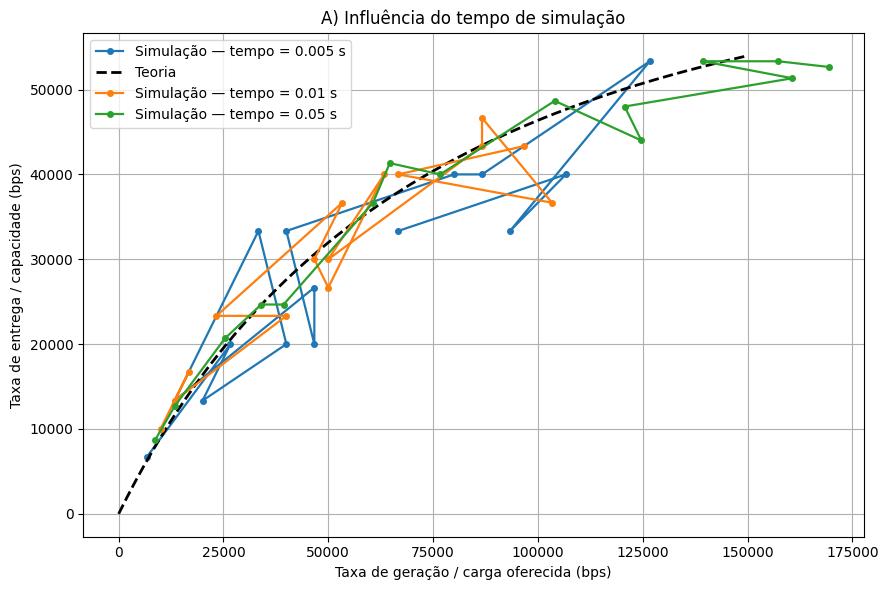

In [18]:
valores_tempo = [0.005, 0.01, 0.05]

plot_variacao_relatorio(
    parametro="tempo",
    valores=valores_tempo,
    base_params=base,
    titulo="A) Influência do tempo de simulação",
    legenda_fmt=lambda v: f"tempo = {v} s",
    arquivo_saida="A_tempo_simulacao.png",
    teoria_modo="unica"
)

O aumento do tempo de simulação não altera a curva teórica, pois o modelo analítico do CSMA não-persistente não depende da duração da execução. Seu efeito ocorre apenas sobre a estimativa experimental. Quando o tempo de simulação é pequeno, há menos eventos observados de transmissão, colisão e retransmissão, o que torna os pontos simulados mais sujeitos a flutuações aleatórias. À medida que o tempo total aumenta, os resultados médios tendem a se estabilizar e a curva simulada se aproxima melhor da curva teórica. Portanto, esse parâmetro influencia principalmente a confiabilidade estatística da simulação.

## B) Influência do número de estações

Nesta análise, varia-se o número de estações que compartilham o meio de transmissão, mantendo os demais parâmetros constantes. O objetivo é observar como a distribuição da carga entre diferentes quantidades de transmissores afeta o comportamento da simulação em comparação com o modelo teórico.

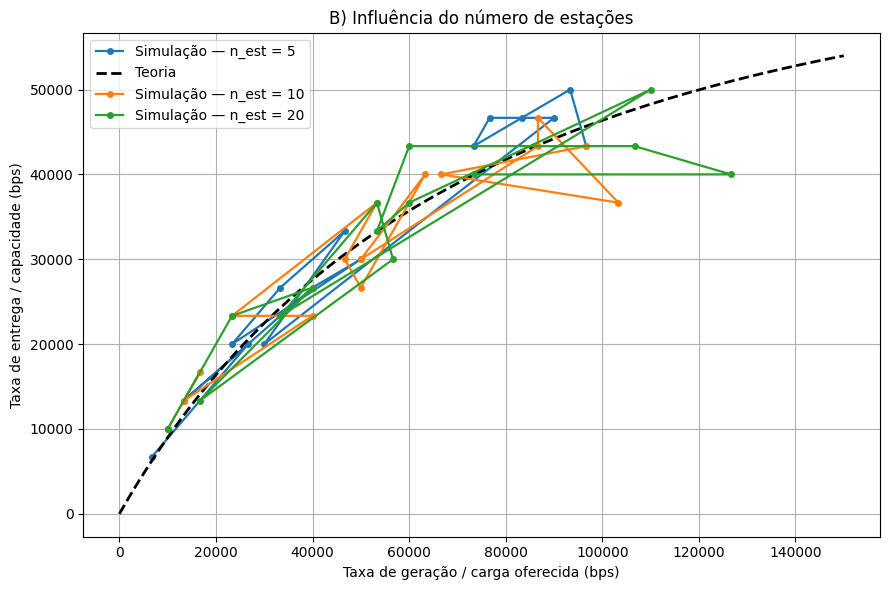

In [19]:
valores_n_est = [5, 10, 20]

plot_variacao_relatorio(
    parametro="n_est",
    valores=valores_n_est,
    base_params=base,
    titulo="B) Influência do número de estações",
    legenda_fmt=lambda v: f"n_est = {v}",
    arquivo_saida="B_numero_estacoes.png",
    teoria_modo="unica"
)

No modelo teórico clássico, o número de estações não aparece explicitamente na expressão da capacidade quando a comparação é feita para uma mesma carga oferecida agregada. Entretanto, na simulação, esse parâmetro influencia a forma como essa carga é distribuída entre as fontes. Com poucas estações, o comportamento tende a ficar mais dependente de eventos individuais e mais sujeito a oscilações. Com mais estações, o tráfego agregado tende a ficar mais distribuído, o que geralmente melhora a aderência às hipóteses médias do modelo. Assim, esse parâmetro afeta principalmente a aproximação prática entre simulação e teoria, e não a curva teórica em si.

## C) Influência da taxa de transmissão

Nesta etapa, varia-se a taxa de transmissão do meio em bits por segundo. O objetivo é verificar como essa alteração modifica a capacidade observada do sistema em termos absolutos e como isso aparece na comparação entre resultados simulados e teóricos.

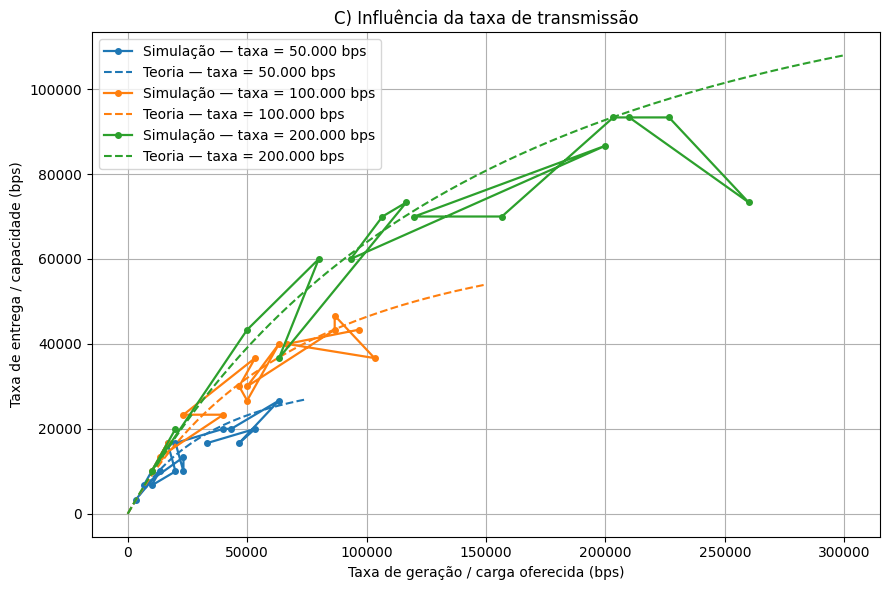

In [20]:
valores_taxa_bits = [5e4, 1e5, 2e5]

plot_variacao_relatorio(
    parametro="taxa_bits",
    valores=valores_taxa_bits,
    base_params=base,
    titulo="C) Influência da taxa de transmissão",
    legenda_fmt=lambda v: f"taxa = {int(v):,} bps".replace(",", "."),
    arquivo_saida="C_taxa_transmissao.png",
    teoria_modo="por_curva"
)

A taxa de transmissão altera diretamente a escala dos resultados em bits por segundo. Quando esse parâmetro aumenta, a capacidade absoluta do canal também aumenta, fazendo com que as curvas de simulação e de teoria sejam deslocadas para valores mais altos no gráfico. Assim, diferentemente dos casos anteriores, a curva teórica também é modificada em termos absolutos. Ainda assim, a lógica de acesso ao meio permanece a mesma, de modo que a principal mudança ocorre na escala de capacidade e não no formato essencial do comportamento do protocolo.

## D) Influência do tamanho do quadro

Nesta análise, varia-se o tamanho do quadro transmitido, mantendo os demais parâmetros fixos. O objetivo é observar como a duração de cada transmissão interfere nos resultados simulados e na comparação com a curva teórica adotada.

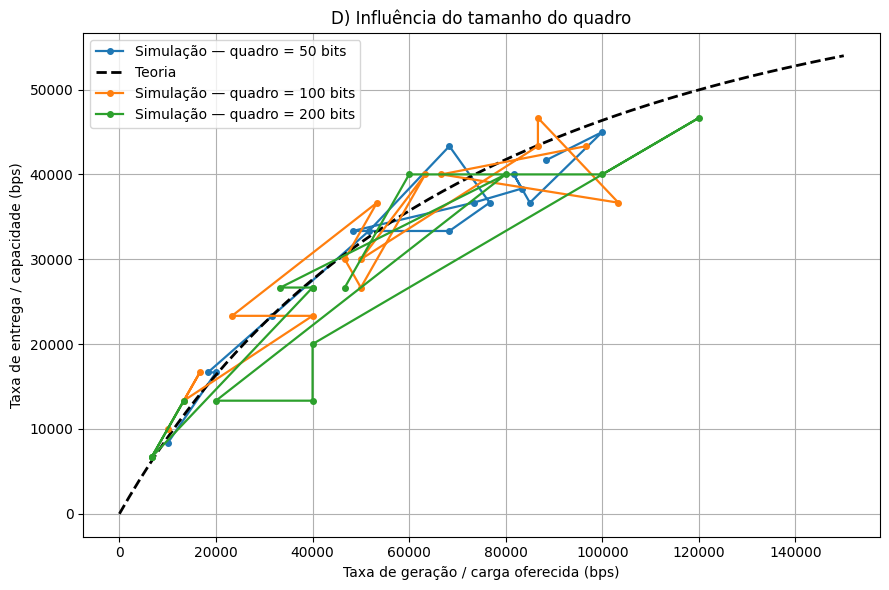

In [21]:
valores_tam_quadro = [50, 100, 200]

plot_variacao_relatorio(
    parametro="tam_quadro",
    valores=valores_tam_quadro,
    base_params=base,
    titulo="D) Influência do tamanho do quadro",
    legenda_fmt=lambda v: f"quadro = {v} bits",
    arquivo_saida="D_tamanho_quadro.png",
    teoria_modo="unica"
)

O tamanho do quadro altera a dinâmica temporal da simulação, pois modifica o tempo necessário para concluir cada transmissão. Quadros maiores mantêm o meio ocupado por mais tempo em cada envio, enquanto quadros menores produzem transmissões mais curtas e mais frequentes. Neste experimento, a comparação teórica foi mantida com a mesma curva de referência, isto é, com o parâmetro \(a\) fixo, para isolar o efeito do tamanho do quadro dentro da simulação. Assim, a diferença observada entre as curvas simuladas decorre do comportamento temporal do sistema simulado, enquanto a curva teórica permanece como referência comum. Em uma situação física real, porém, variar o tamanho do quadro também poderia alterar a razão entre atraso de propagação e tempo de transmissão.

## E) Influência da duração máxima da janela de espera aleatória

Nesta etapa, varia-se o limite máximo do backoff aleatório utilizado após colisões ou quando o meio é percebido como ocupado. O objetivo é verificar como essa escolha influencia o desempenho da simulação em comparação com o modelo teórico.

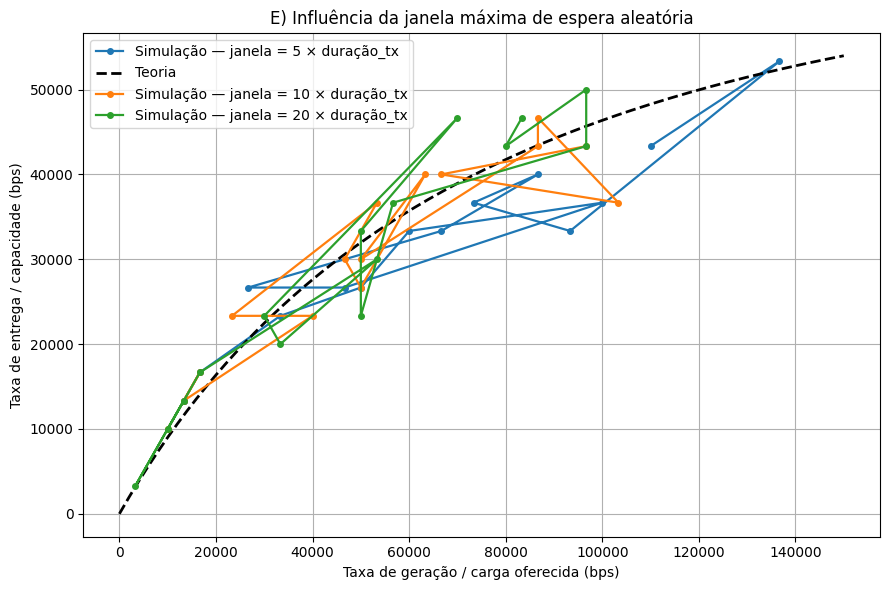

In [22]:
valores_espera = [5, 10, 20]

plot_variacao_relatorio(
    parametro="espera_max_factor",
    valores=valores_espera,
    base_params=base,
    titulo="E) Influência da janela máxima de espera aleatória",
    legenda_fmt=lambda v: f"janela = {v} × duração_tx",
    arquivo_saida="E_janela_espera.png",
    teoria_modo="unica"
)

A duração máxima da janela de espera aleatória não aparece explicitamente no modelo teórico clássico, mas influencia fortemente os resultados da simulação. Quando essa janela é muito pequena, várias estações tendem a retransmitir em instantes próximos, o que aumenta a probabilidade de colisões sucessivas. Quando a janela é muito grande, o sistema passa a desperdiçar tempo com o meio ocioso, reduzindo a taxa de entrega. Dessa forma, esse parâmetro afeta a distância entre a curva simulada e a curva teórica, pois está ligado ao mecanismo prático de retransmissão implementado na simulação.

## F) Influência do número de rodadas de simulação

Nesta análise, varia-se a quantidade de rodadas independentes utilizadas para calcular a média de cada ponto do gráfico. O objetivo é observar como o número de repetições interfere na estabilidade dos resultados simulados.

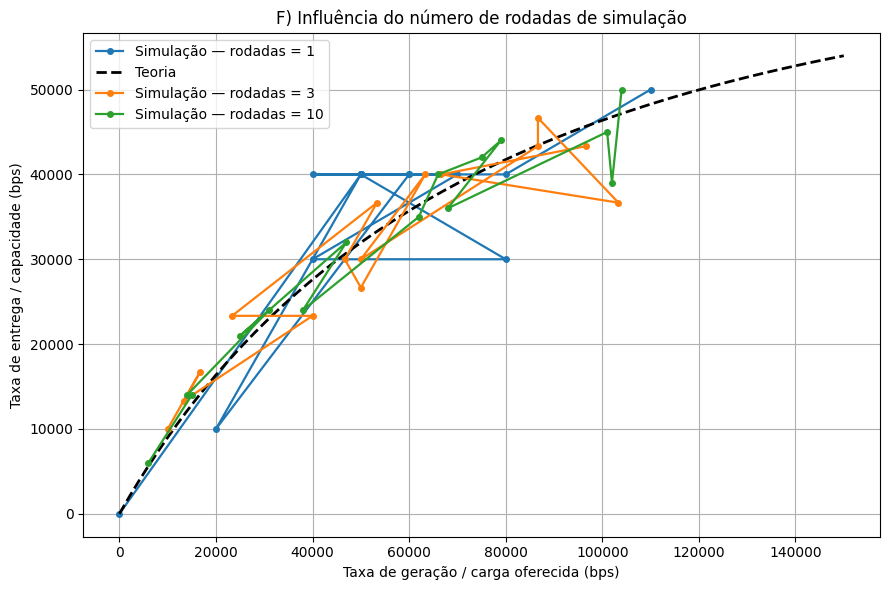

In [23]:
valores_rodadas = [1, 3, 10]

plot_variacao_relatorio(
    parametro="rodadas",
    valores=valores_rodadas,
    base_params=base,
    titulo="F) Influência do número de rodadas de simulação",
    legenda_fmt=lambda v: f"rodadas = {v}",
    arquivo_saida="F_numero_rodadas.png",
    teoria_modo="unica"
)

O número de rodadas não altera a curva teórica do protocolo, pois se trata apenas de um procedimento estatístico de repetição da simulação. Seu efeito aparece sobre a suavidade e a confiabilidade dos pontos experimentais. Com poucas rodadas, os resultados ficam mais sujeitos à variabilidade aleatória de cada execução. Com mais rodadas, os valores médios se tornam mais estáveis e a curva simulada tende a se aproximar melhor da curva teórica. Portanto, esse parâmetro melhora a robustez estatística da análise, sem modificar o modelo analítico.

## G) Influência da relação entre atraso de propagação e tempo de transmissão do quadro

Nesta etapa, varia-se o parâmetro `a`, que representa a razão entre o atraso de propagação e o tempo de transmissão de um quadro. Esse é o parâmetro mais diretamente associado ao modelo teórico do CSMA não-persistente.

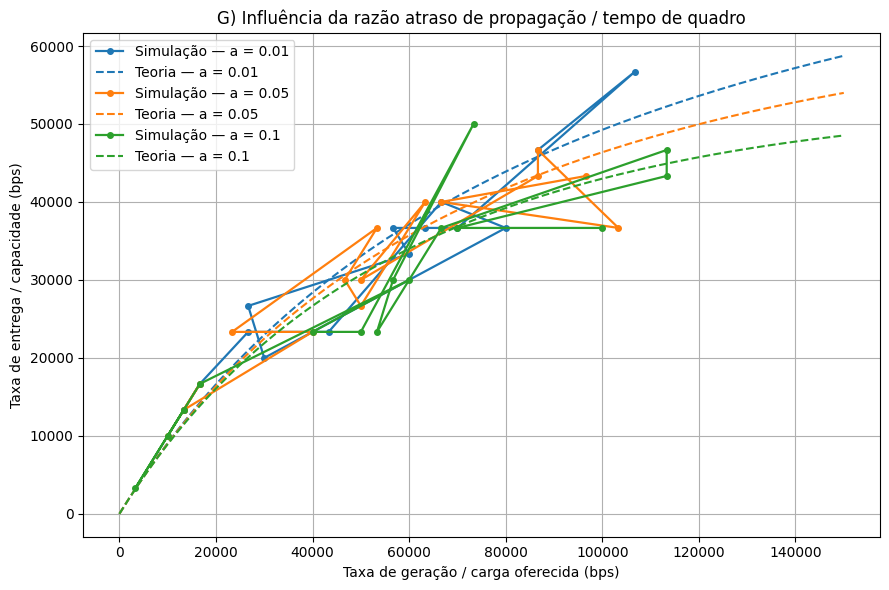

In [24]:
valores_a = [0.01, 0.05, 0.10]

plot_variacao_relatorio(
    parametro="a",
    valores=valores_a,
    base_params=base,
    titulo="G) Influência da razão atraso de propagação / tempo de quadro",
    legenda_fmt=lambda v: f"a = {v}",
    arquivo_saida="G_relacao_atraso_tempo_quadro.png",
    teoria_modo="por_curva"
)

O parâmetro \(a\) é o fator que mais diretamente altera tanto a teoria quanto a simulação. Quando seu valor aumenta, o atraso de propagação passa a representar uma fração maior do tempo de transmissão do quadro, elevando a chance de que duas ou mais estações iniciem transmissão quase simultaneamente. Como consequência, a probabilidade de colisão aumenta e a capacidade máxima do sistema diminui. Por isso, ao aumentar \(a\), tanto a curva teórica quanto a curva simulada tendem a se deslocar para baixo. Esse item representa a comparação mais direta entre o modelo analítico e o comportamento experimental do protocolo.

## Conclusão

A simulação permitiu comparar o comportamento do protocolo CSMA não-persistente com a curva teórica e analisar a influência de diferentes parâmetros sobre o desempenho do sistema. Os resultados mostraram que tempo de simulação e número de rodadas afetam principalmente a estabilidade dos pontos simulados, tornando a curva experimental mais próxima da teórica quando esses valores aumentam.

Também foi possível observar que o número de estações e a janela máxima de espera aleatória influenciam o comportamento prático da simulação, alterando a forma como o sistema se aproxima do modelo ideal. Já a taxa de transmissão e o tamanho do quadro modificam a escala e a dinâmica temporal das transmissões.

Entre todos os parâmetros analisados, a relação entre atraso de propagação e tempo de transmissão do quadro, representada por \(a\), foi a que teve maior impacto direto sobre a capacidade do sistema, pois seu aumento eleva a probabilidade de colisões e reduz o desempenho.

De forma geral, os resultados simulados acompanharam a tendência prevista pela teoria, mostrando que a simulação é adequada para estudar o funcionamento do CSMA não-persistente e compreender como diferentes parâmetros influenciam sua eficiência.